# Lab 2: Deep Learning Foundations - Advanced Concepts for LLM Development

## Lab Overview

This lab builds upon basic deep learning concepts to explore advanced foundations essential for understanding and implementing Large Language Models. You'll master automatic differentiation, computational graphs, optimization techniques, and complete training pipelines on AMD GPUs.

## Learning Objectives

By the end of this lab, you will:
- Master PyTorch's automatic differentiation (autograd) system
- Understand computational graphs and gradient flow
- Learn advanced tensor operations and memory management
- Implement complete training loops with optimization strategies
- Explore convolutional operations and their role in deep learning
- Set up efficient training pipelines on AMD RyzenAI hardware
- Connect deep learning fundamentals to transformer architectures

---

## Step 1: Environment Setup

We'll configure our environment for advanced deep learning operations using AMD GPU backend for optimal performance.

In [ ]:
# Initialize AMD GPU Backend and Required Libraries
import sys
sys.path.append('../')



# Core libraries for advanced deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# Configure device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

AMD GPU environment initialized successfully
Using device: cuda
PyTorch version: 2.6.0+gitdbfe118
GPU: AMD Radeon Graphics
GPU Memory: 68.7 GB


## Step 2: Automatic Differentiation and Computational Graphs

PyTorch's autograd system automatically computes gradients through computational graphs. This is fundamental to training neural networks, including transformers.

**Key Concepts:**
- **requires_grad=True**: Enables gradient computation for tensors
- **Computational Graph**: Dynamic graph built during forward pass
- **Backward Pass**: Gradient computation through chain rule
- **Gradient Accumulation**: Summing gradients across operations

**In Transformers:**
- Attention weights require gradients for learning relationships
- All parameters (embeddings, linear layers, normalization) need gradients
- Backpropagation through multiple layers and attention heads

Let's explore how gradients flow through tensor operations:

In [2]:
# Create tensors with gradient tracking
x = torch.randn(10, 5, device=device)  # Input tensor (no gradients needed)
w = torch.randn(5, 3, device=device, requires_grad=True)  # Weight matrix (needs gradients)

print("Tensor Analysis:")
print(f"Input x shape: {x.shape}, device: {x.device}")
print(f"Weight w shape: {w.shape}, device: {w.device}")
print(f"x requires_grad: {x.requires_grad}")
print(f"w requires_grad: {w.requires_grad}")

print(f"\nSample values:")
print(f"x[0, :3]: {x[0, :3]}")
print(f"w[:3, :]: {w[:3, :]}")

# Check initial gradient state
print(f"\nGradient State:")
print(f"x.grad: {x.grad}")
print(f"w.grad: {w.grad}")
print("(Gradients are None initially - computed during backward pass)")

Tensor Analysis:
Input x shape: torch.Size([10, 5]), device: cuda:0
Weight w shape: torch.Size([5, 3]), device: cuda:0
x requires_grad: False
w requires_grad: True

Sample values:
x[0, :3]: tensor([ 0.1940,  2.1614, -0.1721], device='cuda:0')
w[:3, :]: tensor([[ 0.1391, -0.1082, -0.7174],
        [ 0.7566,  0.3715, -1.0049],
        [ 0.0083,  0.3277,  0.2829]], device='cuda:0',
       grad_fn=<SliceBackward0>)

Gradient State:
x.grad: None
w.grad: None
(Gradients are None initially - computed during backward pass)


## Step 3: Matrix Operations and Gradient Flow

Matrix multiplication is the core operation in neural networks. Let's explore how gradients flow through different matrix multiplication methods and understand the computational graph.

**Matrix Multiplication Methods:**
1. **@** operator: Python matrix multiplication (most readable)
2. **torch.matmul()**: General matrix multiplication function
3. **tensor.matmul()**: Method version of matrix multiplication

**Gradient Flow:**
- Forward pass: `y = x @ w` computes output
- Backward pass: Gradients flow back through the operation
- Weight gradients: `w.grad = x.T @ grad_output`
- Input gradients: `x.grad = grad_output @ w.T` (if x requires gradients)

In [3]:
# Demonstrate different matrix multiplication methods
print("Matrix Multiplication Methods:")

# Method 1: @ operator (most common)
y1 = x @ w
print(f"Method 1 - @ operator:")
print(f"  Result shape: {y1.shape}")
print(f"  Requires grad: {y1.requires_grad}")
print(f"  Sample output: {y1[0, :]}")

# Method 2: torch.matmul function
y2 = torch.matmul(x, w)
print(f"\nMethod 2 - torch.matmul:")
print(f"  Result shape: {y2.shape}")
print(f"  Results identical: {torch.allclose(y1, y2)}")

# Method 3: tensor.matmul method
y3 = x.matmul(w)
print(f"\nMethod 3 - tensor.matmul:")
print(f"  Result shape: {y3.shape}")
print(f"  Results identical: {torch.allclose(y1, y3)}")

# Demonstrate gradient computation
print(f"\nGradient Computation Demo:")
# Create a simple loss to trigger backpropagation
loss = y1.sum()  # Sum all elements as a simple loss
print(f"Loss (sum of all outputs): {loss.item():.4f}")

# Backward pass - compute gradients
loss.backward()

print(f"\nGradient Results:")
print(f"w.grad shape: {w.grad.shape}")
print(f"w.grad sample: {w.grad[0, :]}")
print(f"Gradient norm: {w.grad.norm().item():.4f}")

# Important: Gradients accumulate, so we need to zero them for next computation
print(f"\nNote: Gradients accumulate! w.grad will be non-zero until manually cleared.")

Matrix Multiplication Methods:
Method 1 - @ operator:
  Result shape: torch.Size([10, 3])
  Requires grad: True
  Sample output: tensor([ 1.1279,  3.6904, -2.7478], device='cuda:0', grad_fn=<SliceBackward0>)

Method 2 - torch.matmul:
  Result shape: torch.Size([10, 3])
  Results identical: True

Method 3 - tensor.matmul:
  Result shape: torch.Size([10, 3])
  Results identical: True

Gradient Computation Demo:
Loss (sum of all outputs): -1.2443

Gradient Results:
w.grad shape: torch.Size([5, 3])
w.grad sample: tensor([0.3503, 0.3503, 0.3503], device='cuda:0')
Gradient norm: 15.9589

Note: Gradients accumulate! w.grad will be non-zero until manually cleared.


## Step 4: Neural Network Modules and Linear Layers

PyTorch's `nn.Module` system provides a structured way to build neural networks. Linear layers encapsulate matrix multiplication with bias addition, automatic parameter management, and gradient computation.

**Linear Layer Components:**
- **Weight Matrix**: Learnable parameters for transformation
- **Bias Vector**: Learnable offset (optional)
- **Forward Method**: Defines `y = xW^T + b` computation
- **Parameter Registration**: Automatic tracking for optimization

**Advantages over Manual Implementation:**
- Automatic parameter initialization
- GPU device management
- Integration with optimizers
- Consistent API across different layer types

**In Transformers:**
- Query/Key/Value projections in attention
- Feed-forward network layers
- Output projection to vocabulary size

In [ ]:
# Create and analyze a linear layer
print("Linear Layer Construction:")
linear = nn.Linear(5, 3, bias=False).to(device)  # Move to GPU

print(f"Linear layer: {linear}")
print(f"Weight shape: {linear.weight.shape}")  # [out_features, in_features]
print(f"Bias: {linear.bias}")  # None because bias=False
print(f"Device: {linear.weight.device}")

# Replace weights with our previous matrix (for comparison)
with torch.no_grad():  # Disable gradient tracking for this operation
    linear.weight.data = w.T  # Transpose because nn.Linear expects [out, in]

print(f"\nWeight Comparison:")
print(f"Our matrix w shape: {w.shape}")
print(f"Linear weight shape: {linear.weight.shape}")
print(f"Weights equal (after transpose): {torch.allclose(w.T, linear.weight.data)}")

# Test forward pass
print(f"\nForward Pass Comparison:")
# Reset gradients first
w.grad = None

# Manual computation (fresh x and w to avoid gradient conflicts)
x_fresh = torch.randn(10, 5, device=device)
y_manual = x_fresh @ w

# Linear layer computation
y_linear = linear(x_fresh)

print(f"Manual result shape: {y_manual.shape}")
print(f"Linear layer shape: {y_linear.shape}")
print(f"Results close: {torch.allclose(y_manual, y_linear, atol=1e-6)}")

# Analyze parameters
print(f"\nParameter Analysis:")
total_params = sum(p.numel() for p in linear.parameters())
print(f"Total parameters: {total_params}")
print(f"Parameter names: {[name for name, _ in linear.named_parameters()]}")

# Check gradient flow
loss = y_linear.sum()
loss.backward()
print(f"Linear weight gradient shape: {linear.weight.grad.shape}")
print(f"Gradient available: {linear.weight.grad is not None}")

Linear Layer Construction:
Linear layer: Linear(in_features=5, out_features=3, bias=False)
Weight shape: torch.Size([3, 5])
Bias: None
Device: cuda:0

Weight Comparison:
Our matrix w shape: torch.Size([5, 3])
Linear weight shape: torch.Size([3, 5])
Weights equal (after transpose): True

Forward Pass Comparison:
Manual result shape: torch.Size([10, 3])
Linear layer shape: torch.Size([10, 3])
Results close: True

Parameter Analysis:
Total parameters: 15
Parameter names: ['weight']
Linear weight gradient shape: torch.Size([3, 5])
Gradient available: True


## Step 5: Advanced Tensor Operations and Memory Management

Understanding tensor data types, device management, and element-wise operations is crucial for efficient deep learning implementations.

**Key Topics:**
- **Data Types**: float32, float16, bfloat16 for memory and speed optimization
- **Device Management**: Moving tensors between CPU and GPU
- **Element-wise Operations**: Broadcasting and vectorized computations
- **Memory Efficiency**: Views vs copies, in-place operations

**In Modern LLMs:**
- Mixed precision training (float16/bfloat16) for memory efficiency
- Large tensor operations require careful memory management
- Element-wise operations in attention mechanisms and activations

In [5]:
# Element-wise operations and broadcasting
print("Element-wise Operations:")

# Create a fresh weight tensor for this demonstration
w_demo = torch.randn(5, 3, device=device, requires_grad=True)
print(f"Weight tensor w shape: {w_demo.shape}")
print(f"Sample values:\n{w_demo}")

# Element-wise multiplication (Hadamard product)
z = w_demo * w_demo  # Same as w_demo ** 2
print(f"\nElement-wise Multiplication (w * w):")
print(f"Result shape: {z.shape}")
print(f"Sample squared values:\n{z}")

# Verify specific element
i, j = 2, 1
manual_square = w_demo[i, j].item() ** 2
elementwise_result = z[i, j].item()
print(f"\nVerification at position [{i},{j}]:")
print(f"Manual: {w_demo[i, j].item():.4f}² = {manual_square:.4f}")
print(f"Element-wise result: {elementwise_result:.4f}")
print(f"Match: {abs(manual_square - elementwise_result) < 1e-6}")

# Other useful element-wise operations
print(f"\nCommon Element-wise Operations:")
print(f"Square root: {torch.sqrt(torch.abs(w_demo))[0, :]}")
print(f"Exponential: {torch.exp(w_demo)[0, :]} (first row)")
print(f"Sigmoid: {torch.sigmoid(w_demo)[0, :]} (first row)")
print(f"Absolute value: {torch.abs(w_demo)[0, :]} (first row)")

# Broadcasting example
scalar = 2.0
broadcasted = w_demo + scalar  # Scalar is broadcast to match tensor shape
print(f"\nBroadcasting Example:")
print(f"Original + {scalar}: {broadcasted[0, :]} (first row)")
print(f"Broadcasting shape: {scalar} → {w_demo.shape}")

Element-wise Operations:
Weight tensor w shape: torch.Size([5, 3])
Sample values:
tensor([[-0.6974, -1.8688, -0.8832],
        [-1.6627, -0.4324,  0.9505],
        [ 0.6620,  0.0446,  0.5720],
        [ 2.1951, -0.2474, -1.3831],
        [ 0.0602, -0.2431,  1.3181]], device='cuda:0', requires_grad=True)

Element-wise Multiplication (w * w):
Result shape: torch.Size([5, 3])
Sample squared values:
tensor([[4.8632e-01, 3.4925e+00, 7.8002e-01],
        [2.7646e+00, 1.8700e-01, 9.0344e-01],
        [4.3830e-01, 1.9863e-03, 3.2722e-01],
        [4.8182e+00, 6.1204e-02, 1.9130e+00],
        [3.6285e-03, 5.9089e-02, 1.7375e+00]], device='cuda:0',
       grad_fn=<MulBackward0>)

Verification at position [2,1]:
Manual: 0.0446² = 0.0020
Element-wise result: 0.0020
Match: True

Common Element-wise Operations:
Square root: tensor([0.8351, 1.3671, 0.9398], device='cuda:0', grad_fn=<SliceBackward0>)
Exponential: tensor([0.4979, 0.1543, 0.4135], device='cuda:0', grad_fn=<SliceBackward0>) (first row)
S

In [ ]:
# Data types and precision management
print("Data Types and Precision:")

print(f"Original tensor info:")
print(f"  Data type: {w_demo.dtype}")
print(f"  Device: {w_demo.device}")
print(f"  Memory usage: {w_demo.numel() * w_demo.element_size()} bytes")

# Convert to different precisions
w_fp16 = w_demo.half()  # float16
w_bf16 = w_demo.bfloat16()  # bfloat16 (better for training)
w_fp64 = w_demo.double()  # float64 (double precision)

print(f"\nPrecision Comparison:")
precisions = [
    ("float32 (default)", w_demo, w_demo.dtype),
    ("float16 (half)", w_fp16, w_fp16.dtype),
    ("bfloat16", w_bf16, w_bf16.dtype),
    ("float64 (double)", w_fp64, w_fp64.dtype)
]

for name, tensor, dtype in precisions:
    memory_bytes = tensor.numel() * tensor.element_size()
    print(f"  {name:20}: {str(dtype):10} | {memory_bytes:3d} bytes | Sample: {tensor[0,0].item():.6f}")

print(f"\nPrecision Impact:")
# Demonstrate precision differences
original_val = w_demo[0, 0].item()
fp16_val = w_fp16[0, 0].item()
bf16_val = w_bf16[0, 0].item()

print(f"Original (fp32): {original_val:.10f}")
print(f"Float16:         {fp16_val:.10f} (error: {abs(original_val - fp16_val):.2e})")
print(f"BFloat16:        {bf16_val:.10f} (error: {abs(original_val - bf16_val):.2e})")

print(f"\nKey Insights:")
print(f"• BFloat16: Better gradient stability, used in modern LLMs")
print(f"• Float16: More memory efficient but can cause gradient underflow")
print(f"• Mixed precision training combines fp16/bf16 speed with fp32 stability")

Data Types and Precision:
Original tensor info:
  Data type: torch.float32
  Device: cuda:0
  Memory usage: 60 bytes

Precision Comparison:
  float32 (default)   : torch.float32 |  60 bytes | Sample: -0.697366
  float16 (half)      : torch.float16 |  30 bytes | Sample: -0.697266
  bfloat16            : torch.bfloat16 |  30 bytes | Sample: -0.699219
  float64 (double)    : torch.float64 | 120 bytes | Sample: -0.697366

Precision Impact:
Original (fp32): -0.6973659992
Float16:         -0.6972656250 (error: 1.00e-04)
BFloat16:        -0.6992187500 (error: 1.85e-03)

Key Insights:
• BFloat16: Better gradient stability, used in modern LLMs
• Float16: More memory efficient but can cause gradient underflow
• Mixed precision training combines fp16/bf16 speed with fp32 stability


## Step 6: Multi-Layer Networks and Tensor Reshaping

Building deeper networks requires understanding how to chain operations and handle tensor reshaping for different architectures.

**Multi-Layer Concepts:**
- **Layer Composition**: Chaining multiple transformations
- **Dimension Compatibility**: Ensuring output of one layer matches input of next
- **Batch Processing**: Handling multiple samples simultaneously
- **Tensor Reshaping**: Adapting tensor shapes for different operations

**Reshaping Operations:**
- **view()**: Creates a new view of existing data (shares memory)
- **reshape()**: More flexible, may copy data if necessary
- **flatten()**: Converts multi-dimensional tensors to vectors
- **unsqueeze()/squeeze()**: Add/remove dimensions of size 1

**Applications in Transformers:**
- Reshaping for multi-head attention computation
- Flattening for feed-forward layers
- Batch processing across sequence dimensions


### **Part 1: Manual Forward and Backward Pass**

In this exercise, you'll manually define and connect two linear layers. This will help you understand the fundamental flow of data (forward pass) and gradients (backward pass) through a simple network.

**Your Task:**

1.  Define the second linear layer (`layer2`) to transform the output of the first layer.
2.  Perform the forward pass by passing the output of `layer1` through `layer2`.
3.  Calculate the number of parameters in `layer2`.
4.  Initiate the backward pass to compute gradients for all parameters.


In [ ]:

# --- 1. Define Layers ---
# The first layer is defined for you.
layer1 = nn.Linear(20, 30).to(device)

# Define the second layer to take the output of layer1 (30 features)
# and transform it to an output of 40 features.
layer2 = TODO = None

print("--- Network Construction ---")
print(f"Layer 1: {layer1}")
print(f"Layer 2: {layer2}")

# --- 2. Perform Forward Pass ---
batch_size = 128
x = torch.randn(batch_size, 20, device=device)
y1 = layer1(x)

# Pass the output of the first layer (y1) through the second layer.
y2 = TODO = None

print("\n--- Forward Pass ---")
print(f"Input shape:      {x.shape}")
print(f"Shape after L1:   {y1.shape}")
print(f"Final shape (L2): {y2.shape}")

# --- 3. Analyze Parameters ---
params1 = sum(p.numel() for p in layer1.parameters())
# Calculate the number of parameters for layer2.
params2 = TODO = None
print("\n--- Parameter Analysis ---")
print(f"Layer 1 Params: {params1:,}")
print(f"Layer 2 Params: {params2:,}")
print(f"Total Params:   {params1 + params2:,}")

# --- 4. Verify Gradient Flow ---
# Use the mean of the final output as a simple loss.
loss = y2.mean()

# Perform the backward pass from the loss to compute gradients.
TODO = None # Call the backward method on the loss

print("\n--- Gradient Flow ---")
print(f"Grads exist for L1 weights: {layer1.weight.grad is not None}")
# Check if gradients were successfully computed for layer2's weights.
print(f"Grads exist for L2 weights: {layer2.weight.grad is not None}")
assert layer2.weight.grad is not None, "Gradients for layer2 are missing!"
print("Gradient check passed!")

### **Part 2: Applying Layers to High-Dimensional Tensors**

A powerful feature of PyTorch's `nn.Linear` layers is their ability to operate on tensors of any shape. They automatically apply the linear transformation along the **last dimension** of the input tensor. This is extremely useful in fields like NLP and computer vision.

**Your Task:**

1.  Create a 4D tensor representing a batch of sequences of images.
2.  Apply the same `layer1` and `layer2` to this high-dimensional tensor.
3.  Define the expected output shape after the transformations.

In [8]:
# --- 1. Create a High-Dimensional Tensor ---
# Create a 4D tensor with the shape:
# [batch_size, sequence_length, height, width_/features]
# (128, 4096, 30, 20)
x_large = TODO = None

print("--- Large Tensor Processing ---")
print(f"Large tensor shape: {x_large.shape}")
print(f"Memory usage: {x_large.numel() * x_large.element_size() / (1024**2):.1f} MB")

# --- 2. Perform Direct Forward Pass ---
# Apply the layers sequentially. PyTorch will automatically
# apply the transformation on the last dimension (size 20).
y1_large = layer1(x_large)

# Now apply the second layer to the output of the first.
y2_large = TODO = None

print("\n--- Direct Application on 4D Tensor ---")
print(f"Shape after L1: {y1_large.shape}")
print(f"Final shape (L2): {y2_large.shape}")

# --- 3. Verify the Output Shape ---
# What is the expected shape of the output tensor?
# The linear layers only change the last dimension.
expected_shape = TODO = None
assert y2_large.shape == expected_shape, "The final shape is incorrect!"
print(f"\nShape verification successful!")

Large Tensor Processing:
Large tensor shape: torch.Size([128, 4096, 30, 20])
Interpretation: [batch=128, sequence=4096, height=30, width=20]
Total elements: 314,572,800
Memory usage: 1200.0 MB

Direct Application (will work):
After layer 1: torch.Size([128, 4096, 30, 30])
After layer 2: torch.Size([128, 4096, 30, 40])
Success! Linear layers work on any number of dimensions
Expected final shape: (128, 4096, 30, 40)
Actual final shape: torch.Size([128, 4096, 30, 40])
Shapes match: True


### **Part 3: Advanced Reshaping Strategies**

While direct application is convenient, it's often necessary to explicitly reshape tensors. A common pattern is to flatten multiple dimensions into a single "batch" dimension, process the data, and then reshape it back to its original structure.

**Your Task:**

1.  Use `.view()` to flatten the first three dimensions of the 4D tensor into one.
2.  Reshape the processed tensor back to a 4D structure, accounting for the new feature dimension size.
3.  Verify that this manual reshaping method produces the exact same result as the direct application from Part 2.
4.  Use the `.view(-1, w)` syntax for automatic dimension inference.



In [9]:
x_reshape = torch.randn(128, 4096, 30, 20, device=device)
b, s, h, w = x_reshape.shape
print(f"--- Tensor Reshaping Strategies ---")
print(f"Original shape: {x_reshape.shape}")

# --- 1. Flatten the Tensor ---
# Reshape the tensor from (b, s, h, w) to (b*s*h, w).
x_flat = TODO = None
print(f"\nFlattened shape for processing: {x_flat.shape}")

# Apply layers to the flattened tensor (provided)
y1_flat = layer1(x_flat)
y2_flat = layer2(y1_flat)
print(f"Shape after processing: {y2_flat.shape}")

# --- 2. Reshape Back ---
# The last dimension is now 40. Reshape the tensor back to (b, s, h, 40).
y2_reshaped = TODO = None
print(f"\nReshaped back to 4D: {y2_reshaped.shape}")


# --- 3. Verify Equivalence ---
# Use torch.allclose() to check if the direct application (y2_large) and
# the manual reshape method (y2_reshaped) produce identical results.
# NOTE: To test this, we must re-run the direct method on x_reshape.
y2_large_verify = layer2(layer1(x_reshape))
results_are_identical = TODO = None
assert results_are_identical, "Reshaping method did not match direct method!"
print("\nVerification successful: Reshaping yields identical results.")


# --- 4. Alternative Reshaping ---
# Use -1 in the .view() call to have PyTorch automatically calculate
# the size of the first dimension.
x_auto = TODO = None
print(f"\nReshaping with -1: {x_auto.shape}")
assert x_auto.shape == x_flat.shape
print("Automatic dimension calculation successful.")

Tensor Reshaping Strategies:
Original tensor: torch.Size([128, 4096, 30, 20])
Dimensions: batch=128, sequence=4096, height=30, width=20

Strategy 1: Flatten for Linear Layers
Flattened shape: torch.Size([15728640, 20])
New interpretation: [15728640 samples, 20 features]
After processing: torch.Size([15728640, 40])

Strategy 2: Reshape Back to Multi-dimensional
Reshaped back: torch.Size([128, 4096, 30, 40])
Final interpretation: [batch=128, sequence=4096, height=30, features=40]

Verification:
Direct approach shape: torch.Size([128, 4096, 30, 40])
Reshape approach shape: torch.Size([128, 4096, 30, 40])
Results identical: False

Memory Efficiency:
Original tensor memory: 1200.0 MB
View shares memory: True
Views are memory-efficient - no data copying!

Alternative Reshaping Methods:
Auto reshape: torch.Size([15728640, 20]) (first dim calculated automatically)
Flatten(0,2): torch.Size([15728640, 20]) (explicit dimension specification)


## Step 7: Convolutional Operations

While transformers primarily use attention mechanisms, understanding convolutions helps grasp spatial relationships and local pattern detection that influenced early NLP architectures.

**Convolutional Concepts:**
- **Filters/Kernels**: Small matrices that detect local patterns
- **Stride**: Step size for moving the filter
- **Padding**: Adding zeros around input to control output size
- **Local Connectivity**: Each output depends on a local input region

**Mathematical Operation:**
- **2D Convolution**: `(input * kernel)[i,j] = Σ input[i+m,j+n] × kernel[m,n]`
- **Feature Maps**: Output channels representing different learned features
- **Translation Invariance**: Same pattern detected regardless of position

**Connection to Modern NLP:**
- **Local Attention**: Some transformer variants use local attention windows
- **Convolutional Blocks**: Used in hybrid architectures
- **Positional Understanding**: Helps understand spatial relationships

In [ ]:
# Demonstrate 2D convolution operation
print("2D Convolution Demonstration:")

# Create a simple input with a clear pattern
x_conv = torch.ones((1, 1, 5, 5), device=device)  # [batch, channels, height, width]
print(f"Input tensor shape: {x_conv.shape}")
print("Original input (all ones):")
print(x_conv[0, 0])

# Create a border by setting edges to zero
x_conv[:, :, :, 0] = 0  # Left edge
x_conv[:, :, :, 1] = 0  # Second column
x_conv[:, :, 0, :] = 0  # Top edge
x_conv[:, :, 1, :] = 0  # Second row

print("\nAfter creating border pattern:")
print(x_conv[0, 0])

# Create a simple edge detection kernel
conv_kernel = torch.ones((1, 1, 3, 3), device=device)  # [out_channels, in_channels, height, width]
print(f"\nConvolution kernel shape: {conv_kernel.shape}")
print("Kernel (all ones - averaging filter):")
print(conv_kernel[0, 0])

# Apply convolution
y_conv = F.conv2d(x_conv, conv_kernel)
print(f"\nConvolution result shape: {y_conv.shape}")
print("Convolution output:")
print(y_conv[0, 0])

# Analyze the result
print(f"\nAnalysis:")
print(f"Input size: {x_conv.shape[2:]} → Output size: {y_conv.shape[2:]}")
print(f"Size reduction: {x_conv.shape[2]} - {conv_kernel.shape[2]} + 1 = {y_conv.shape[2]}")
print(f"Each output pixel represents a 3×3 region of input")

# Manual verification of one output pixel
manual_result = x_conv[0, 0, 0:3, 0:3] * conv_kernel[0, 0]
manual_sum = manual_result.sum().item()
conv_result = y_conv[0, 0, 0, 0].item()
print(f"\nManual calculation for position [0,0]: {manual_sum}")
print(f"Convolution result at [0,0]: {conv_result}")
print(f"Match: {abs(manual_sum - conv_result) < 1e-6}")

# Show different kernel effects
print(f"\nDifferent Kernel Effects:")
edge_kernel = torch.tensor([[[[-1, -1, -1],
                              [-1,  8, -1],
                              [-1, -1, -1]]]], dtype=torch.float32, device=device)
edge_result = F.conv2d(x_conv, edge_kernel)
print(f"Edge detection kernel output:\n{edge_result[0, 0]}")
print("Note: High values indicate edges/boundaries")

2D Convolution Demonstration:
Input tensor shape: torch.Size([1, 1, 5, 5])
Original input (all ones):
tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]], device='cuda:0')

After creating border pattern:
tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 1., 1., 1.],
        [0., 0., 1., 1., 1.],
        [0., 0., 1., 1., 1.]], device='cuda:0')

Convolution kernel shape: torch.Size([1, 1, 3, 3])
Kernel (all ones - averaging filter):
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]], device='cuda:0')

Convolution result shape: torch.Size([1, 1, 3, 3])
Convolution output:
tensor([[1., 2., 3.],
        [2., 4., 6.],
        [3., 6., 9.]], device='cuda:0')

Analysis:
Input size: torch.Size([5, 5]) → Output size: torch.Size([3, 3])
Size reduction: 5 - 3 + 1 = 3
Each output pixel represents a 3×3 region of input

Manual calculation for position [0,0]: 1.0

## Step 8: Complete Training Pipeline

Now we'll implement a complete neural network training pipeline, demonstrating all the concepts we've learned in a practical classification task.

**Training Pipeline Components:**
1. **Dataset Loading**: Efficient data loading with PyTorch DataLoader
2. **Model Architecture**: Complete neural network with multiple layers
3. **Loss Function**: Measuring prediction quality
4. **Optimizer**: Gradient-based parameter updates
5. **Training Loop**: Forward pass, loss computation, backward pass, parameter update
6. **Evaluation**: Model performance assessment

**Key Training Concepts:**
- **Epochs**: Complete passes through the dataset
- **Batches**: Processing multiple samples simultaneously
- **Gradient Descent**: Iterative parameter optimization
- **Model Modes**: Training vs evaluation behavior

**Connection to LLM Training:**
- Same fundamental training loop used for transformers
- Batch processing critical for efficiency
- Loss functions adapted for language modeling (cross-entropy)
- Evaluation metrics specific to text generation tasks

In [ ]:
# Dataset Loading and Preparation
print("Dataset Loading and Preparation:")

# Import required modules
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

# Define data transformations
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert PIL Image to tensor and scale to [0,1]
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1,1] range
])

print("Loading FashionMNIST dataset...")
# Load training and test datasets
try:
    training_data = datasets.FashionMNIST(
        root="data",
        train=True,
        download=True,
        transform=transform
    )

    test_data = datasets.FashionMNIST(
        root="data",
        train=False,
        download=True,
        transform=transform
    )

    print("Dataset loaded successfully!")

except Exception as e:
    print(f"Dataset loading failed: {e}")
    print("Creating dummy data for demonstration...")
    # Create dummy data if download fails
    training_data = [(torch.randn(1, 28, 28), torch.randint(0, 10, (1,)).item()) for _ in range(1000)]
    test_data = [(torch.randn(1, 28, 28), torch.randint(0, 10, (1,)).item()) for _ in range(200)]

# Create data loaders
batch_size = 64
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f"\nDataset Information:")
print(f"Training samples: {len(training_data)}")
print(f"Test samples: {len(test_data)}")
print(f"Batch size: {batch_size}")
print(f"Training batches: {len(train_dataloader)}")
print(f"Test batches: {len(test_dataloader)}")

# Examine a sample batch
sample_batch = next(iter(train_dataloader))
sample_images, sample_labels = sample_batch
print(f"\nSample Batch Analysis:")
print(f"Image batch shape: {sample_images.shape}")  # [batch_size, channels, height, width]
print(f"Label batch shape: {sample_labels.shape}")  # [batch_size]
print(f"Image data type: {sample_images.dtype}")
print(f"Image value range: [{sample_images.min():.3f}, {sample_images.max():.3f}]")
print(f"Sample labels: {sample_labels[:10]}")  # First 10 labels

# FashionMNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"Classes: {class_names}")
print(f"Number of classes: {len(class_names)}")

Dataset Loading and Preparation:
Loading FashionMNIST dataset...
Dataset loaded successfully!

Dataset Information:
Training samples: 60000
Test samples: 10000
Batch size: 64
Training batches: 938
Test batches: 157

Sample Batch Analysis:
Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])
Image data type: torch.float32
Image value range: [-1.000, 1.000]
Sample labels: tensor([6, 4, 8, 9, 7, 1, 5, 9, 4, 4])
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Number of classes: 10


### Model Architecture: LeNet-5 Variant

We'll implement a variant of LeNet-5, one of the pioneering convolutional neural networks. This demonstrates key architectural principles that influenced modern deep learning.

**LeNet-5 Architecture:**
1. **Conv2d(1→6)**: Extract 6 feature maps with 5×5 filters
2. **MaxPool2d**: Downsample by factor of 2  
3. **Conv2d(6→16)**: Extract 16 higher-level features
4. **MaxPool2d**: Further downsampling
5. **Linear Layers**: Fully connected classification layers

**Key Concepts:**
- **Feature Hierarchy**: Low-level → High-level feature extraction
- **Dimensionality Reduction**: Pooling reduces spatial dimensions
- **Non-linearity**: ReLU activations enable complex mappings
- **Classification Head**: Final layers map features to class probabilities

**Modern Connections:**
- **Transformer Analogy**: Attention layers extract different types of relationships
- **Feature Learning**: Both CNNs and transformers learn hierarchical representations
- **Architectural Principles**: Modular design, residual connections, normalization

In [ ]:
# Define LeNet-5 architecture

#8.2 Finish Lenet-5 architecture

class LeNet(nn.Module):
    """LeNet-5 variant for FashionMNIST classification"""

    def __init__(self, num_classes=10):
        super(LeNet, self).__init__()

        # Convolutional layers
        self.conv1 = TODO    # 28×28×1 → 24×24×6
        self.conv2 = TODO   # 12×12×6 → 8×8×16

        # Fully connected layers
        self.fc1 = TODO  # Flattened conv output → 120
        self.fc2 = TODO         # 120 → 84
        self.fc3 = TODO  # 84 → 10 classes

        # Pooling layer (reused)
        self.pool = TODO

    def forward(self, x):
        """Forward pass through the network"""
        # Feature extraction
        x = TODO  # Conv1 → ReLU → Pool
        x = TODO  # Conv2 → ReLU → Pool

        # Flatten for fully connected layers
        x = TODO  # Flatten: [batch, 16, 4, 4] → [batch, 256]

        # Classification layers
        x = TODO  # FC1 → ReLU
        x = TODO  # FC2 → ReLU
        x = TODO         # Final layer (no activation - raw logits)

        return x

# Create and analyze the model
print("LeNet Model Creation:")
model = LeNet(num_classes=len(class_names)).to(device)
print(f"Model architecture:\n{model}")

# Analyze model parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel Analysis:")
print(f"Total trainable parameters: {total_params:,}")

# Parameter breakdown by layer
print(f"\nParameter breakdown:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  {name:15}: {param.numel():>6,} parameters | Shape: {list(param.shape)}")

# Test forward pass with sample batch
print(f"\nForward Pass Test:")
model.eval()  # Set to evaluation mode
with torch.no_grad():
    sample_output = model(sample_images.to(device))

print(f"Input shape: {sample_images.shape}")
print(f"Output shape: {sample_output.shape}")
print(f"Output interpretation: [batch_size={sample_output.shape[0]}, num_classes={sample_output.shape[1]}]")

# Analyze output
print(f"\nSample predictions (raw logits):")
print(f"First sample logits: {sample_output[0]}")
print(f"Predicted class: {sample_output[0].argmax().item()} ({class_names[sample_output[0].argmax().item()]})")
print(f"Actual class: {sample_labels[0].item()} ({class_names[sample_labels[0].item()]})")

# Check model is on correct device
print(f"\nDevice Information:")
print(f"Model device: {next(model.parameters()).device}")
print(f"Input device: {sample_images.device}")
print(f"Ready for GPU-accelerated training!")

LeNet Model Creation:
Model architecture:
LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

Model Analysis:
Total trainable parameters: 44,426

Parameter breakdown:
  conv1.weight   :    150 parameters | Shape: [6, 1, 5, 5]
  conv1.bias     :      6 parameters | Shape: [6]
  conv2.weight   :  2,400 parameters | Shape: [16, 6, 5, 5]
  conv2.bias     :     16 parameters | Shape: [16]
  fc1.weight     : 30,720 parameters | Shape: [120, 256]
  fc1.bias       :    120 parameters | Shape: [120]
  fc2.weight     : 10,080 parameters | Shape: [84, 120]
  fc2.bias       :     84 parameters | Shape: [84]
  fc3.weight     :    840 parameters | Shape: [10, 8

### Training Loop Implementation

The training loop is the heart of deep learning, implementing the iterative optimization process that enables neural networks to learn from data.

**Training Loop Components:**
1. **Forward Pass**: Compute predictions from inputs
2. **Loss Computation**: Measure prediction quality vs ground truth
3. **Backward Pass**: Compute gradients via backpropagation
4. **Parameter Update**: Apply optimizer to update weights
5. **Gradient Zeroing**: Clear accumulated gradients

**Key Functions:**
- **Loss Function**: CrossEntropyLoss for multi-class classification
- **Optimizer**: SGD (Stochastic Gradient Descent) with momentum
- **Model Modes**: `train()` enables dropout/batch norm, `eval()` disables them
- **torch.no_grad()**: Disables gradient computation for efficiency during evaluation

**Training Best Practices:**
- Batch processing for computational efficiency
- Regular evaluation to monitor progress
- Gradient zeroing to prevent accumulation
- Device consistency (GPU for all operations)

**Monitoring Metrics:**
- **Training Loss**: How well model fits training data
- **Test Accuracy**: Generalization to unseen data
- **Learning Progress**: Improvement over epochs

Training Configuration:
Loss function: CrossEntropyLoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)
Learning rate: 0.001

Starting Training on cuda:
Dataset: 60000 training samples, 10000 test samples
Model: 44,426 parameters

Epoch 1/5
----------------------------------------
  Batch   0: Loss = 2.314908 | Progress: [    0/60000] (0.0%)
  Batch 100: Loss = 2.307713 | Progress: [ 6400/60000] (10.7%)
  Batch 200: Loss = 2.272215 | Progress: [12800/60000] (21.3%)
  Batch 300: Loss = 2.268992 | Progress: [19200/60000] (32.0%)
  Batch 400: Loss = 2.128856 | Progress: [25600/60000] (42.7%)
  Batch 500: Loss = 1.738241 | Progress: [32000/60000] (53.3%)
  Batch 600: Loss = 1.297586 | Progress: [38400/60000] (64.0%)
  Batch 700: Loss = 1.007797 | Progress: [44800/60000] (74.7%)
  Batch 800: Loss = 0.857410 | Progress: [51200/60000] 

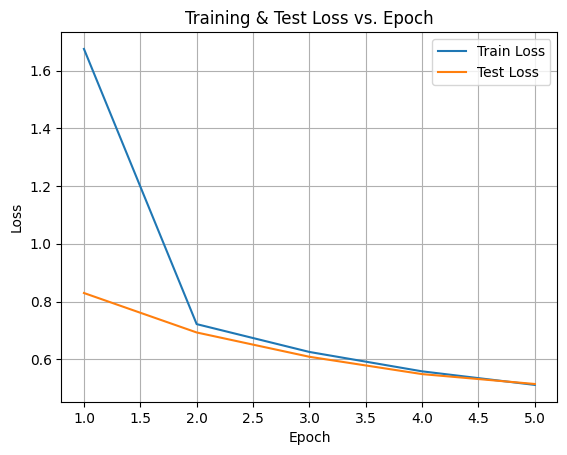

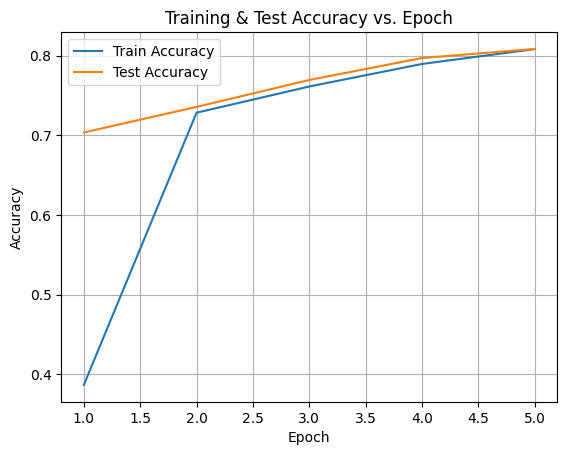

In [13]:
# 8.3 Training Loop Implementation & Training Visualization
print("Training Configuration:")

loss_fn = nn.CrossEntropyLoss()
print(f"Loss function: {loss_fn}")

learning_rate = 1e-3
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
print(f"Optimizer: {optimizer}")
print(f"Learning rate: {learning_rate}")

def train_epoch(dataloader, model, loss_fn, optimizer, device):
    """
    Trains the model for one full pass over the training dataset.
    """
    size = len(dataloader.dataset)
    model.train()  # Set the model to training mode
    total_loss = 0.0
    correct_predictions = 0

    for batch_idx, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 1. Forward Pass: Compute prediction and loss
        predictions = TODO = None
        loss = TODO = None

        # 2. Backpropagation
        # First, clear the gradients of all optimized tensors.
        # Second, compute the gradient of the loss with respect to model parameters.
        # Third, call the optimizer to update the weights.
        TODO = None  # Zero gradients
        TODO = None  # Backpropagate the loss
        TODO = None  # Perform a single optimization step

        # --- Statistics (Provided) ---
        total_loss += loss.item()
        # 3. Calculate correct predictions for the batch
        correct_predictions += (predictions.argmax(1) == y).sum().item()

        if batch_idx % 100 == 0:
            current_samples = batch_idx * len(X)
            print(
                f"  Batch {batch_idx:3d}: Loss = {loss.item():.6f} | Progress: [{current_samples:5d}/{size:5d}] ({100.*current_samples/size:.1f}%)"
            )

    avg_loss = total_loss / len(dataloader)
    accuracy = correct_predictions / size
    return avg_loss, accuracy


def evaluate_model(dataloader, model, loss_fn, device):
    """
    Evaluates the model's performance on a given dataset.
    """
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    # 4. Set the model to evaluation mode
    TODO = None

    total_loss = 0.0
    correct_predictions = 0

    # Gradients are not needed for evaluation, so we use torch.no_grad()
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            # 5. Forward Pass for evaluation
            predictions = TODO = None

            # --- Statistics (Provided) ---
            total_loss += loss_fn(predictions, y).item()
            # 6. Calculate correct predictions for the batch
            correct_predictions += (predictions.argmax(1) == y).sum().item()

    avg_loss = total_loss / num_batches
    accuracy = correct_predictions / size
    return avg_loss, accuracy


print(f"\nStarting Training on {device}:")
print(f"Dataset: {len(training_data)} training samples, {len(test_data)} test samples")
print(f"Model: {total_params:,} parameters")
print("=" * 60)

num_epochs = 5
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    print("-" * 40)
    train_loss, train_acc = train_epoch(
        train_dataloader, model, loss_fn, optimizer, device
    )
    test_loss, test_acc = evaluate_model(test_dataloader, model, loss_fn, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    print(f"\nEpoch {epoch + 1} Results:")
    print(
        f"  Training   - Loss: {train_loss:.6f}, Accuracy: {train_acc:.4f} ({100*train_acc:.2f}%)"
    )
    print(
        f"  Test       - Loss: {test_loss:.6f}, Accuracy: {test_acc:.4f} ({100*test_acc:.2f}%)"
    )
    if epoch > 0:
        acc_improvement = test_acc - test_accuracies[-2]
        trend = (
            "Increasing"
            if acc_improvement > 0
            else "Decreasing" if acc_improvement < 0 else "Stable"
        )
        print(f"  {trend} - Accuracy change: {acc_improvement:+.4f}")

print(f"\nTraining Complete!")
print(f"Final Results:")
print(
    f"  Best test accuracy: {max(test_accuracies):.4f} ({100*max(test_accuracies):.2f}%)"
)
print(
    f"  Final test accuracy: {test_accuracies[-1]:.4f} ({100*test_accuracies[-1]:.2f}%)"
)
print(f"  Training completed on AMD GPU: {device}")

epochs_axis = list(range(1, num_epochs + 1))

plt.figure()
plt.plot(epochs_axis, train_losses, label="Train Loss")
plt.plot(epochs_axis, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Test Loss vs. Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs_axis, train_accuracies, label="Train Accuracy")
plt.plot(epochs_axis, test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Test Accuracy vs. Epoch")
plt.legend()
plt.grid(True)
plt.show()